<a href="https://colab.research.google.com/github/MuntasirAraf14/EDA_-Exploratory-Data-Analysis-/blob/main/EDA_project(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# US Accidents Exploratory Data **Analysis**
TODO - talk about EDA

TODO - talk about the dataset(source, what it contains, how it will be useful)
*   Kaggle
*   Information about accidents

*   can be useful to prevent accidents







In [1]:
pip install opendatasets --upgrade --quiet


##Download Data


In [2]:
import opendatasets as od

download_url = 'https://www.kaggle.com/datasets/sobhanmoosavi/us-accidents'

od.download(download_url)


Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username:  mdmuntasirazadaraf
Your Kaggle Key: ··········
Dataset URL: https://www.kaggle.com/datasets/sobhanmoosavi/us-accidents


100%|██████████| 653M/653M [00:07<00:00, 95.2MB/s]


In [3]:
data_filename = './us-accidents/US_Accidents_March23.csv'

In [4]:
import os

data_filename = './us-accidents/US_Accidents_March23.csv'
size = os.path.getsize(data_filename)
print(f"File size: {size / (1024**3):.2f} GB")

File size: 2.85 GB


##Data Preparation and Cleaning


*   Load the file using Pandas
*   Look at some information about the data &    the columns

*   Fix any missing or incorrect values



In [5]:
import pandas as pd

In [6]:
import pandas as pd

chunk_size = 200000

for df in pd.read_csv(data_filename, chunksize=chunk_size):
    # Perform EDA on each chunk
    print(df.describe())

            Severity      Start_Lat      Start_Lng  End_Lat  End_Lng  \
count  200000.000000  200000.000000  200000.000000      0.0      0.0   
mean        2.410060      35.402579    -104.355926      NaN      NaN   
std         0.494724       4.582634      17.870632      NaN      NaN   
min         1.000000      25.433098    -123.813927      NaN      NaN   
25%         2.000000      33.754379    -118.437279      NaN      NaN   
50%         2.000000      34.120522    -117.370598      NaN      NaN   
75%         3.000000      38.514824     -83.764334      NaN      NaN   
max         4.000000      44.895218     -70.590034      NaN      NaN   

        Distance(mi)  Temperature(F)  Wind_Chill(F)    Humidity(%)  \
count  200000.000000    197165.00000   21390.000000  196757.000000   
mean        0.033965        65.68728      30.399621      63.903195   
std         0.535451        16.43741      19.850108      21.603255   
min         0.000000       -13.00000     -29.300000       4.000000   
2

In [7]:
df.columns

Index(['ID', 'Source', 'Severity', 'Start_Time', 'End_Time', 'Start_Lat',
       'Start_Lng', 'End_Lat', 'End_Lng', 'Distance(mi)', 'Description',
       'Street', 'City', 'County', 'State', 'Zipcode', 'Country', 'Timezone',
       'Airport_Code', 'Weather_Timestamp', 'Temperature(F)', 'Wind_Chill(F)',
       'Humidity(%)', 'Pressure(in)', 'Visibility(mi)', 'Wind_Direction',
       'Wind_Speed(mph)', 'Precipitation(in)', 'Weather_Condition', 'Amenity',
       'Bump', 'Crossing', 'Give_Way', 'Junction', 'No_Exit', 'Railway',
       'Roundabout', 'Station', 'Stop', 'Traffic_Calming', 'Traffic_Signal',
       'Turning_Loop', 'Sunrise_Sunset', 'Civil_Twilight', 'Nautical_Twilight',
       'Astronomical_Twilight'],
      dtype='object')

In [8]:
len(df.columns)

46

In [9]:
numerics = ['int16', 'int32', 'int64', 'float16', 'float32', 'float64']

numeric_df = df.select_dtypes(include=numerics)
len(numeric_df.columns)

13

#Percantage of Missing values in one column








In [10]:
missing_percentages = df.isna().sum().sort_values(ascending=False)/len(df)*100
missing_percentages

,0
Precipitation(in),40.305622
Wind_Chill(F),38.464414
Wind_Speed(mph),10.160132
Weather_Condition,2.873966
Visibility(mi),2.787513
Humidity(%),2.440145
Wind_Direction,2.423789
Temperature(F),2.372385
Pressure(in),2.188576
Weather_Timestamp,1.720485


<Axes: >

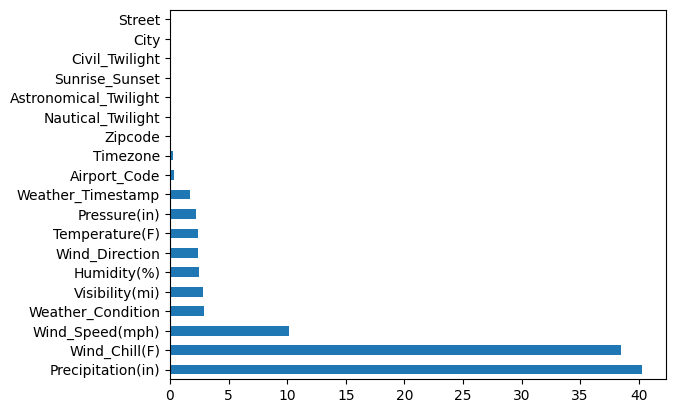

In [11]:
missing_percentages[missing_percentages != 0].plot(kind='barh')

#Remove Columns that we don't want to use

##Exploratory Analysis & Visualization


Columns we'll analyze :


*   City

*   Start Time

*   Start Lat, Start Lng

*   Temperature
*   Weather Condition



In [12]:
df.City

,City
7600000,Charlotte
7600001,Atlanta
7600002,Brooksville
7600003,Hollywood
7600004,Lake City
...,...
7728389,Riverside
7728390,San Diego
7728391,Orange
7728392,Culver City


In [15]:
cities = df.City.unique()
len(cities)

5986

In [17]:
cities_by_accident = df.City.value_counts()
cities_by_accident[:10]

,count
City,
Los Angeles,2501
Houston,2259
Portland,2248
Miami,1947
Chicago,1927
Dallas,1886
Salt Lake City,1836
Atlanta,1714
Charlotte,1530


In [18]:
'New York' in cities

True

<Axes: ylabel='City'>

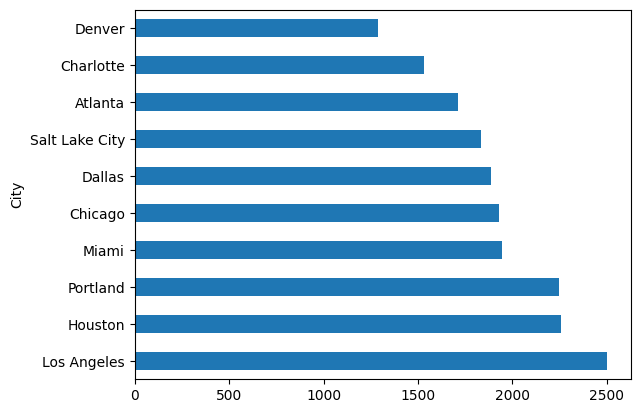

In [20]:
cities_by_accident[:10].plot(kind='barh')

In [21]:
import seaborn as sns

In [22]:
sns.set_style('darkgrid')

/tmp/ipykernel_850/80215261.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(cities_by_accident[:10])


<Axes: xlabel='count', ylabel='Density'>

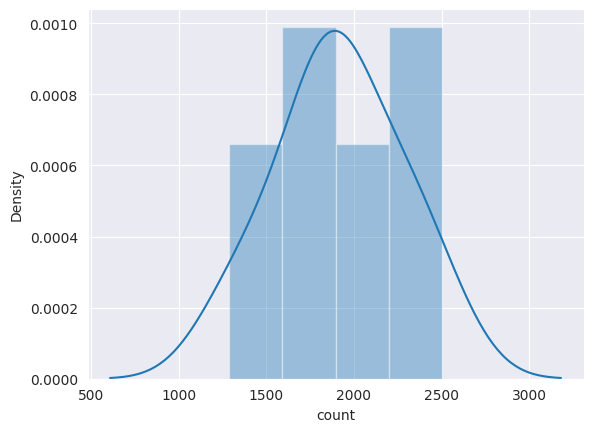

In [24]:
sns.d istplot(cities_by_accident[:10])

In [27]:
high_accident_cities = cities_by_accident[cities_by_accident >= 1000]
len(high_accident_cities)


12

In [28]:
low_accident_cities = cities_by_accident[cities_by_accident < 1000]
len(low_accident_cities)

5973

/tmp/ipykernel_850/2843252471.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(high_accident_cities)


<Axes: xlabel='count', ylabel='Density'>

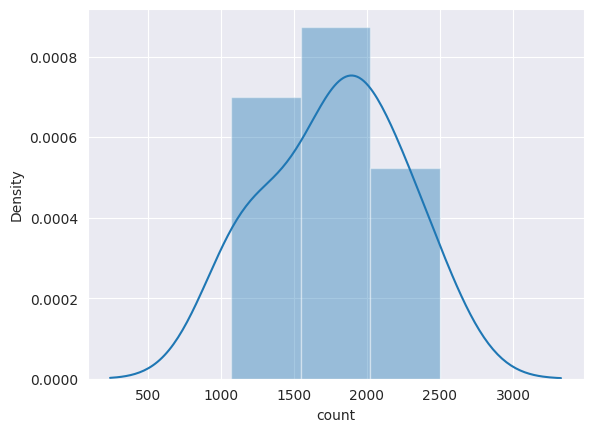

In [29]:
sns.distplot(high_accident_cities)

/tmp/ipykernel_850/469555131.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(low_accident_cities)


<Axes: xlabel='count', ylabel='Density'>

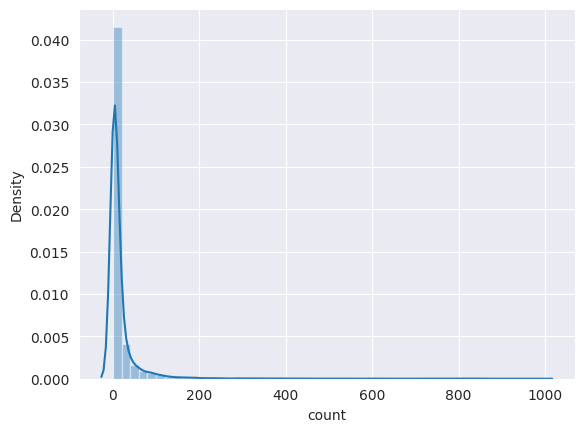

In [30]:
sns.distplot(low_accident_cities)

In [31]:
cities_by_accident[cities_by_accident == 1]

,count
City,
Hope Valley,1
Grayling,1
Kingfield,1
Mena,1
Trinity Center,1
...,...
Weeki Wachee,1
White Bird,1
Valleyford,1


##Ask & Answer Questions



*   Are there more accidents in warmer or colder areas?
*   Which 5 states have the highest number of accident? How about per capita?

* Does New Yourk show up in the data? If yes, why is the count lower if this is the most populated city?

*Among the top 100 cities in number of accidents, which states do they belong to most frequently.


##Summary and Conclusion


#Insights:

*   The number of accidents per city decreases exponentially
*   Less than 5% of cities have more than yearly 1000 accidents
* Over 1200 cities have reported just one accident (need to investigate)

